Code example for a 4 qubit NN system that saves the hardware results to a directory for future reference and plots the relevant graphs.
This was done similarly for all system sizes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import pickle
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice


In [ ]:
folder_path = r"Folder\Hardware Data\hardwaredata_N4_firstorder_400shots"

file_pattern = os.path.join(folder_path, "time_*.txt")
files = glob.glob(file_pattern)

if not files:
    raise FileNotFoundError(f"No files found at {file_pattern}")



In [ ]:
# List single excitation states
intended_states = ["1000", "0100", "0010", "0001"]

all_data = []

In [5]:
for file in files:
    df = pd.read_csv(file, sep=r'\s+', engine='python')
    
    if 'time' not in df.columns:
        continue

    row_dict = df.iloc[0].to_dict()
    all_data.append(row_dict)
master_df = pd.DataFrame(all_data).sort_values(by='time').fillna(0.0)


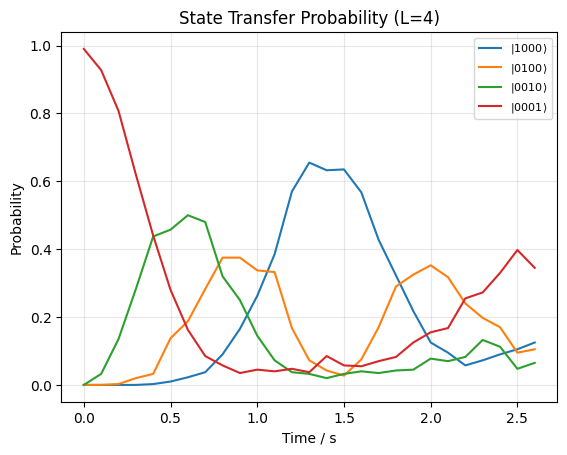

In [ ]:
# Plot raw data
for col in intended_states:
    if col in master_df.columns:
        plt.plot(
            master_df['time'], 
            master_df[col], 
            label=f"$|{col}\\rangle$",  
        )
    else:
        print(f"Warning: State {col} not found in the data files.")

plt.xlabel("Time / s")
plt.ylabel("Probability")
plt.title("State Transfer Probability (L=4)")
plt.legend(fontsize=8, loc="best")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Process of normalising the data by disregarding bit flip errors
time = master_df['time'].values
eps = 1e-12

P_1p = master_df[intended_states].sum(axis=1).values

In [8]:
renorm_data = {}
for state in intended_states:
    renorm_data[f"{state}_ren"] = master_df[state].values / (P_1p + eps)


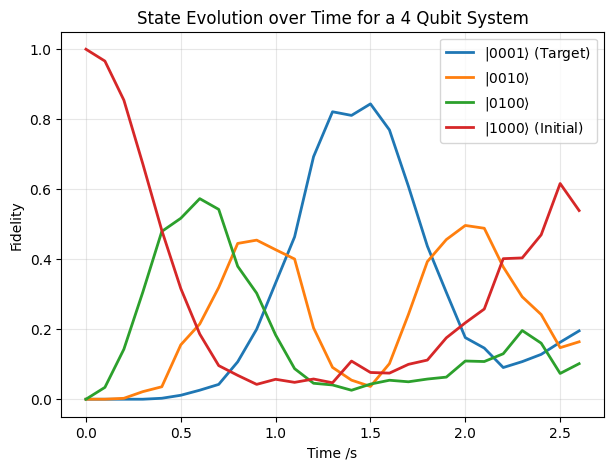

In [ ]:
# Plot renormalised data
labels = {
    "1000": r"$|0001\rangle$ (Target)",
    "0100": r"$|0010\rangle$",
    "0010": r"$|0100\rangle$",
    "0001": r"$|1000\rangle$ (Initial)"
}

plt.figure(figsize=(7,5))
for state in intended_states:
    plt.plot(time, renorm_data[f"{state}_ren"], lw=2, label=labels.get(state, state))

plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title(f"State Evolution over Time for a 4 Qubit System")
#plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

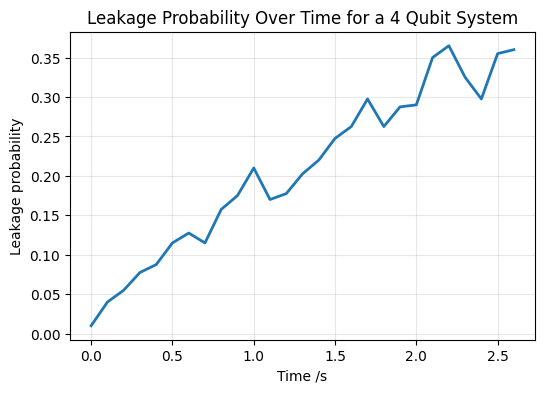

In [ ]:
# Plot leakeage (error accumulation) over time 
P_leak = 1.0 - P_1p
plt.figure(figsize=(6,4))
plt.plot(time, P_leak, lw=2)
plt.title("Leakage Probability Over Time for a 4 Qubit System")
plt.xlabel("Time /s")
plt.ylabel("Leakage probability")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Save the data
out_dir = Path(r"Folder\Hardware Data")
out_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    out_dir / "fidelity_data400shots_L4_renorm.npz",
    time=time,
    P_1000_ren=renorm_data["1000_ren"],
    P_0100_ren=renorm_data["0100_ren"],
    P_0010_ren=renorm_data["0010_ren"],
    P_0001_ren=renorm_data["0001_ren"],
    P_leak=P_leak
)

print(f"File saved successfully to: {out_dir / 'fidelity_data400shots_L4_renorm.npz'}")


In [12]:
np.savez(
    out_dir / "leakage_L4.npz", 
    time=time, 
    P_leak=P_leak
)

Final Graph

In [ ]:
N_QUBITS = 4   # alter to any number

os.environ["AWS_ACCESS_KEY_ID"]="access key ID"
os.environ["AWS_SECRET_ACCESS_KEY"]="access key"
os.environ["AWS_SESSION_TOKEN"]= "session token"
os.environ["AWS_DEFAULT_REGION"] = "region"
USE_IONQ_QPU = False


# XY interaction
def xy_interaction(circuit, q1, q2, theta):
    circuit.xx(q1, q2, theta)
    circuit.rz(q1, np.pi / 2)
    circuit.rz(q2, np.pi / 2)
    circuit.xx(q1, q2, theta)
    circuit.rz(q1, -np.pi / 2)
    circuit.rz(q2, -np.pi / 2)




# Trotter circuit
def xy_trotter_circuit(n_qubits, J, total_time, dt):
    trotter_steps = int(total_time / dt)
    theta = J * dt

    circuit = Circuit()

    # Initial state: excitation at last qubit
    circuit.x(n_qubits - 1)

    for _ in range(trotter_steps):
        for i in range(n_qubits - 1):
            xy_interaction(circuit, i, i + 1, theta)

    return circuit



# Device setup (only once)
if USE_IONQ_QPU:
    device = AwsDevice("device")
    print("\n[HARDWARE MODE]")
else:
    device = LocalSimulator()
    print("\n[LOCAL SIMULATOR MODE]")



# Run simulation
tasks = []
times_MS = []

dt = 0.1
times_MS = np.arange(0, 2.7, dt)

for time2 in times_MS:

    circuit = xy_trotter_circuit(
        n_qubits=N_QUBITS,
        J=-2.0,
        total_time=time2,
        dt=dt
    )

    # Measure all qubits and add measurements
    for q in range(N_QUBITS):
        circuit.measure(q)

    task = device.run(circuit, shots=400)
    tasks.append(task)



# Get results
fidelities = []

print("\nRetrieving results...\n")

# target state = excitation moved to first qubit
target_state = "1" + "0" * (N_QUBITS - 1)

for time2, task in zip(times_MS, tasks):
    result = task.result()
    counts = result.measurement_counts

    shots = sum(counts.values())
    fidelity = counts.get(target_state, 0) / shots if shots > 0 else 0

    fidelities.append(fidelity)

    print(f"[RESULT] t = {time2:.2f} | fidelity = {fidelity:.3f}")

print(times_MS)
print(fidelities)


[LOCAL SIMULATOR MODE]

Retrieving results...

[RESULT] t = 0.00 | fidelity = 0.000
[RESULT] t = 0.10 | fidelity = 0.000
[RESULT] t = 0.20 | fidelity = 0.000
[RESULT] t = 0.30 | fidelity = 0.000
[RESULT] t = 0.40 | fidelity = 0.000
[RESULT] t = 0.50 | fidelity = 0.000
[RESULT] t = 0.60 | fidelity = 0.030
[RESULT] t = 0.70 | fidelity = 0.043
[RESULT] t = 0.80 | fidelity = 0.110
[RESULT] t = 0.90 | fidelity = 0.195
[RESULT] t = 1.00 | fidelity = 0.357
[RESULT] t = 1.10 | fidelity = 0.468
[RESULT] t = 1.20 | fidelity = 0.655
[RESULT] t = 1.30 | fidelity = 0.835
[RESULT] t = 1.40 | fidelity = 0.943
[RESULT] t = 1.50 | fidelity = 0.983
[RESULT] t = 1.60 | fidelity = 0.927
[RESULT] t = 1.70 | fidelity = 0.833
[RESULT] t = 1.80 | fidelity = 0.723
[RESULT] t = 1.90 | fidelity = 0.485
[RESULT] t = 2.00 | fidelity = 0.330
[RESULT] t = 2.10 | fidelity = 0.152
[RESULT] t = 2.20 | fidelity = 0.040
[RESULT] t = 2.30 | fidelity = 0.003
[RESULT] t = 2.40 | fidelity = 0.003
[RESULT] t = 2.50 | fidelit

: 

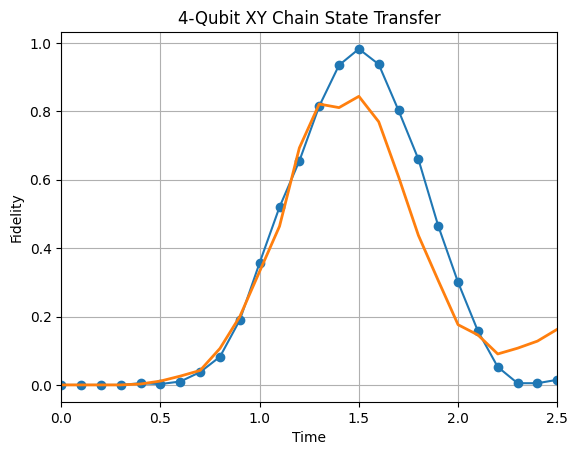

In [ ]:
# Plot
state = "1000"
plt.figure()
plt.plot(times_MS, fidelities, marker='o')
plt.plot(time,  renorm_data[f"{state}_ren"], lw=2)
plt.xlim(0,2.5)
plt.xlabel("Time")
plt.ylabel("Fidelity")
plt.title(f"{N_QUBITS}-Qubit XY Chain State Transfer")
plt.grid(True)
plt.show()

In [ ]:
# Plot against saved simulations from Final_Script
# Parameters
s = N_QUBITS
total_time = 6
J_in = 1.0
alpha = 5
ns_str = "5-20-50-100"

old_dir =Path(
    r"Folder"
)

# Load simulation file
pkl_file = old_dir / f"simulation_L{s}_T{total_time}_J{J_in}_a{alpha}_ns{ns_str}.pkl"
if not pkl_file.exists():
    raise FileNotFoundError(f"Could not find {pkl_file}")

with open(pkl_file, "rb") as f:
    r = pickle.load(f)

print(f"Loaded simulation file: {pkl_file}")


In [16]:
# Extract NN data from pkl
t_exact = np.array(r["exact"]["NN"]["times"])
F_exact = np.array(r["exact"]["NN"]["F"])
peak_times_exact = np.array(r["exact"]["NN"]["peak_times"])
peak_values_exact = np.array(r["exact"]["NN"]["peak_values"])
# Display n = 50
n_plot = int(ns_str.split("-")[2])

if n_plot not in r["trotter"]["NN"]:
    raise KeyError(f"Trotter NN data for n={n_plot} not found in file")

if n_plot not in r["gate"]["NN"]:
    raise KeyError(f"Gate NN data for n={n_plot} not found in file")

t_trotter_50 = np.array(r["trotter"]["NN"][50]["times"])
F_trotter_50 = np.array(r["trotter"]["NN"][50]["F"])
t_trotter_20 = np.array(r["trotter"]["NN"][20]["times"])
F_trotter_20 = np.array(r["trotter"]["NN"][20]["F"])


peak_times_trotter = np.array(r["trotter"]["NN"][n_plot]["peak_times"])
peak_values_trotter = np.array(r["trotter"]["NN"][n_plot]["peak_values"])

t_gate = np.array(r["gate"]["NN"][n_plot]["times"])
F_gate = np.array(r["gate"]["NN"][n_plot]["F"])
peak_times_gate = np.array(r["gate"]["NN"][n_plot]["peak_times"])
peak_values_gate = np.array(r["gate"]["NN"][n_plot]["peak_values"])

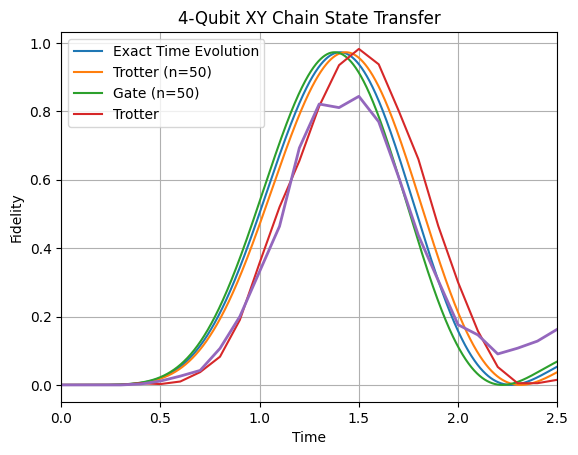

In [ ]:
# Plot all data
state = "1000"
plt.figure()
plt.plot(t_exact, F_exact, label="Exact Time Evolution")
plt.plot(t_trotter_50, F_trotter_50, label=f"Trotter (n={n_plot})")
plt.plot(t_gate, F_gate, label=f"Gate (n={n_plot})")
plt.plot(times_MS, fidelities, label=f"Trotter")
plt.plot(time,  renorm_data[f"{state}_ren"], lw=2)
plt.xlim(0,2.5)
plt.xlabel("Time")
plt.ylabel("Fidelity")
plt.title(f"{N_QUBITS}-Qubit XY Chain State Transfer")
plt.grid(True)
plt.legend()
plt.show()

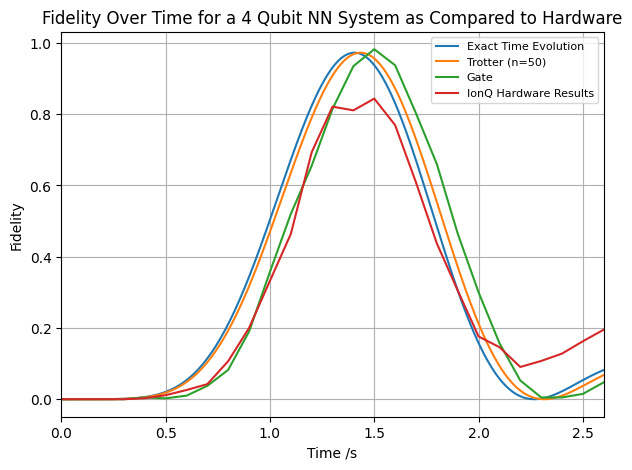

In [ ]:
# Plot what is required
plt.figure(figsize=(7,5))
plt.plot(t_exact, F_exact, label="Exact Time Evolution")
plt.plot(t_trotter_50, F_trotter_50, label=f"Trotter (n=50)")
plt.plot(times_MS, fidelities, label=f"Gate")
plt.plot(time,  renorm_data[f"{state}_ren"],  label="IonQ Hardware Results")
plt.xlim(0,time[-1])
plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title(f"Fidelity Over Time for a {N_QUBITS} Qubit NN System as Compared to Hardware")
plt.grid(True)
plt.legend(fontsize=8, loc="best")
plt.show()